<a href="https://colab.research.google.com/github/JulieBarny/Store_Sales_Kaggle/blob/origin-master/Stores_Sales_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Store Sales - Time Series Forecasting**

*We import first the needed libraries*

In [1]:
import numpy
import pandas as pd
import seaborn as sns
import sklearn
from sklearn import linear_model
import matplotlib.pyplot as plt


**1)** We will try to observ the tendencies



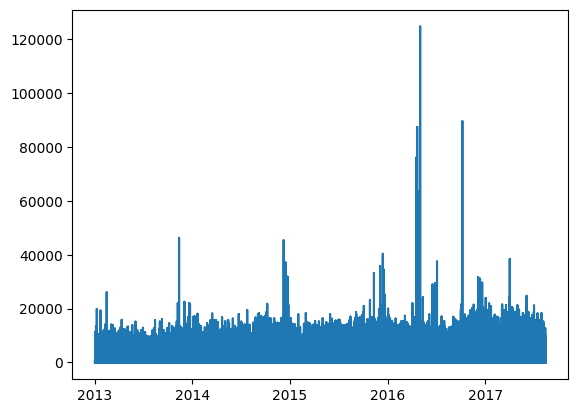

In [2]:
train_data = pd.read_csv("train.csv")
train_data["date"] = pd.to_datetime(train_data["date"])
plt.plot(train_data["date"] ,train_data["sales"])
plt.show()

The values are roughly close to the average, with two significant peaks.

In [3]:
holiday_df= pd.read_csv("holidays_events.csv")
holiday_df["date"] =pd.to_datetime(holiday_df["date"])

In [4]:
train_data = train_data.merge(holiday_df[["date" , "type"]], on = 'date' , how = 'left')
train_data.head(10)

,id,date,store_nbr,family,sales,onpromotion,type
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Holiday
1,1,2013-01-01,1,BABY CARE,0.0,0,Holiday
2,2,2013-01-01,1,BEAUTY,0.0,0,Holiday
3,3,2013-01-01,1,BEVERAGES,0.0,0,Holiday
4,4,2013-01-01,1,BOOKS,0.0,0,Holiday
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,Holiday
6,6,2013-01-01,1,CELEBRATION,0.0,0,Holiday
7,7,2013-01-01,1,CLEANING,0.0,0,Holiday
8,8,2013-01-01,1,DAIRY,0.0,0,Holiday
9,9,2013-01-01,1,DELI,0.0,0,Holiday


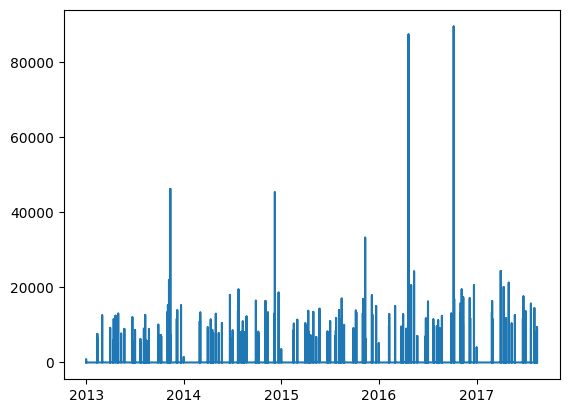

In [5]:

holiday_data = train_data[train_data["type"]== "Holiday"]
plt.plot( holiday_data["date"], holiday_data["sales"])

In [6]:

train_data = pd.get_dummies(train_data , columns = ['family' , 'type'])
print(train_data.columns)


Index(['id', 'date', 'store_nbr', 'sales', 'onpromotion', 'family_AUTOMOTIVE',
       'family_BABY CARE', 'family_BEAUTY', 'family_BEVERAGES', 'family_BOOKS',
       'family_BREAD/BAKERY', 'family_CELEBRATION', 'family_CLEANING',
       'family_DAIRY', 'family_DELI', 'family_EGGS', 'family_FROZEN FOODS',
       'family_GROCERY I', 'family_GROCERY II', 'family_HARDWARE',
       'family_HOME AND KITCHEN I', 'family_HOME AND KITCHEN II',
       'family_HOME APPLIANCES', 'family_HOME CARE', 'family_LADIESWEAR',
       'family_LAWN AND GARDEN', 'family_LINGERIE', 'family_LIQUOR,WINE,BEER',
       'family_MAGAZINES', 'family_MEATS', 'family_PERSONAL CARE',
       'family_PET SUPPLIES', 'family_PLAYERS AND ELECTRONICS',
       'family_POULTRY', 'family_PREPARED FOODS', 'family_PRODUCE',
       'family_SCHOOL AND OFFICE SUPPLIES', 'family_SEAFOOD',
       'type_Additional', 'type_Bridge', 'type_Event', 'type_Holiday',
       'type_Transfer', 'type_Work Day'],
      dtype='object')


In [10]:
train_data["day"] = train_data['date'].dt.day
train_data["month"] = train_data["date"].dt.month
train_data["dayofweek"] = train_data["date"].dt.dayofweek
train_data= train_data.drop(columns = ["date"] , axis = 1)

In [11]:
train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]] = train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]].fillna(0)
train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]] = train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]].astype(int)

In [12]:
print(train_data.dtypes)

id                                     int64
store_nbr                              int64
sales                                float64
onpromotion                            int64
family_AUTOMOTIVE                       bool
family_BABY CARE                        bool
family_BEAUTY                           bool
family_BEVERAGES                        bool
family_BOOKS                            bool
family_BREAD/BAKERY                     bool
family_CELEBRATION                      bool
family_CLEANING                         bool
family_DAIRY                            bool
family_DELI                             bool
family_EGGS                             bool
family_FROZEN FOODS                     bool
family_GROCERY I                        bool
family_GROCERY II                       bool
family_HARDWARE                         bool
family_HOME AND KITCHEN I               bool
family_HOME AND KITCHEN II              bool
family_HOME APPLIANCES                  bool
family_HOM

In [13]:

X_train = train_data.drop("sales" , axis = 1)
y_train= train_data["sales"]


We choose first Linear Regression

In [14]:
regression_model = linear_model.LinearRegression()
regression_model.fit(X_train , y_train)

LinearRegression()

In [24]:
test_data = pd.read_csv("test.csv")
print(test_data)

            id        date  store_nbr                      family  onpromotion
0      3000888  2017-08-16          1                  AUTOMOTIVE            0
1      3000889  2017-08-16          1                   BABY CARE            0
2      3000890  2017-08-16          1                      BEAUTY            2
3      3000891  2017-08-16          1                   BEVERAGES           20
4      3000892  2017-08-16          1                       BOOKS            0
...        ...         ...        ...                         ...          ...
28507  3029395  2017-08-31          9                     POULTRY            1
28508  3029396  2017-08-31          9              PREPARED FOODS            0
28509  3029397  2017-08-31          9                     PRODUCE            1
28510  3029398  2017-08-31          9  SCHOOL AND OFFICE SUPPLIES            9
28511  3029399  2017-08-31          9                     SEAFOOD            0

[28512 rows x 5 columns]


In [25]:
test_data["date"]= pd.to_datetime(test_data["date"] , errors ="coerce")
test_data["day"] = test_data['date'].dt.day
test_data["month"] = test_data["date"].dt.month
test_data["dayofweek"] = test_data["date"].dt.dayofweek
test_data= test_data.drop(columns = ["date"] , axis = 1)

In [29]:
test_data = pd.get_dummies(test_data , columns = ['family'])
X_test = test_data.drop(columns = ["sales"] , axis = 1)

KeyError: "None of [Index(['family'], dtype='object')] are in the [columns]"

KeyError: "['sales'] not found in axis"

In [31]:
regression_model.predict(test_data)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- type_Additional
- type_Bridge
- type_Event
- type_Holiday
- type_Transfer
- ...
